# 제주 농산물 가격 예측 프로젝트

## 1. 환경 설정 및 데이터 로드

In [11]:
import os
import pandas as pd
import numpy as np
import datetime
import holidays
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# 폰트 설정: korean_font.py 필수 사용
try:
    from korean_font import set_korean_font
    set_korean_font()
    print("korean_font.py 설정 완료")
except:
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import VotingRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

DATA_PATH = './data/'
train = pd.read_csv(os.path.join(DATA_PATH, 'train.csv'))
test = pd.read_csv(os.path.join(DATA_PATH, 'test.csv'))
train['timestamp'] = pd.to_datetime(train['timestamp'])
test['timestamp'] = pd.to_datetime(test['timestamp'])

print(f"데이터 로드 완료. Train: {train.shape}")

한글 폰트 설정: NanumGothic (/usr/share/fonts/truetype/nanum/NanumGothic.ttf)
korean_font.py 설정 완료
데이터 로드 완료. Train: (59397, 7)


## 2. 통합 데이터 분석 (EDA)

### 2.1 품목별 시계열 가격 추세
- 연도별/계절별 가격 변동 패턴 시각화

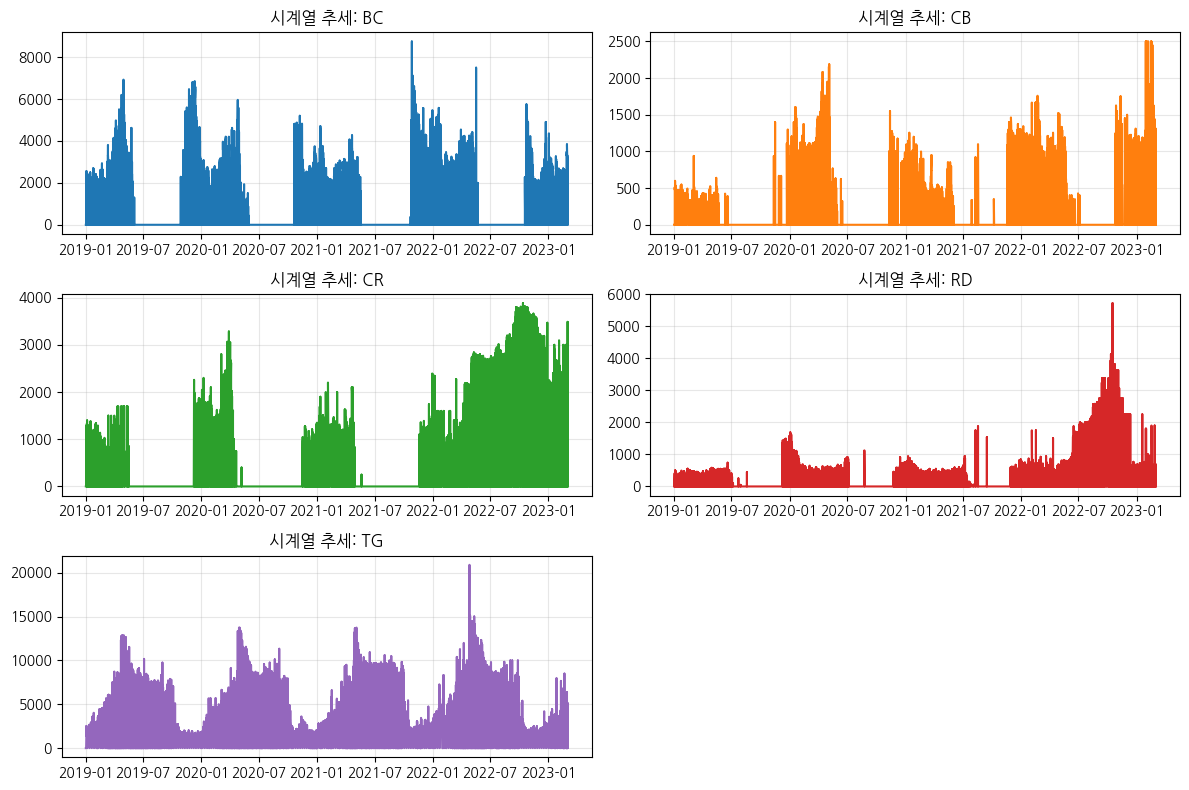

In [12]:
plt.figure(figsize=(12,8))
items = sorted(train['item'].unique())
for i, item in enumerate(items):
    plt.subplot(3, 2, i+1)
    item_data = train[train['item'] == item].sort_values('timestamp')
    plt.plot(item_data['timestamp'], item_data['price(원/kg)'], label=item, color=f'C{i}')
    plt.title(f'시계열 추세: {item}')
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

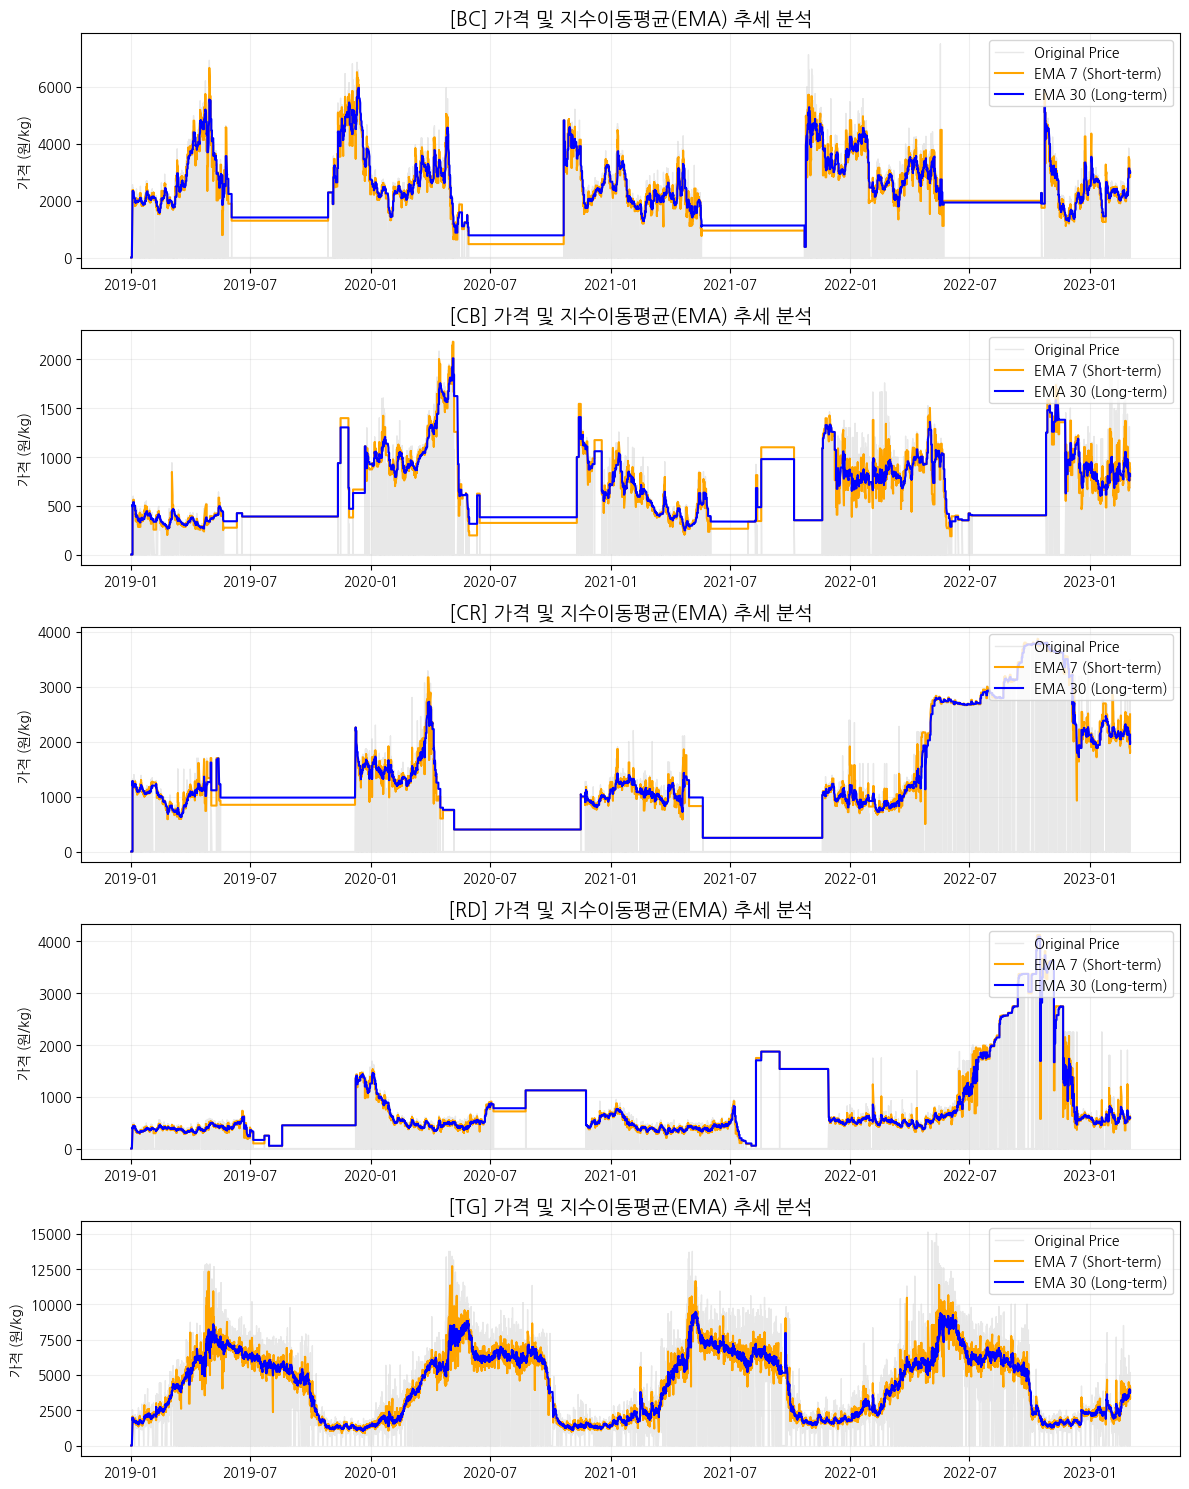

In [21]:
def calculate_ema_viz(series, window):
    # 0원을 NaN으로 바꾸어 계산에서 제외하고, 계산 후 다시 채움
    s = series.replace(0, np.nan)
    ema = s.ewm(span=window, min_periods=1).mean()
    return ema.ffill().fillna(0)

plt.figure(figsize=(12, 15))
for i, item in enumerate(items):
    plt.subplot(5, 1, i+1)
    df_item = train[train['item'] == item].sort_values('timestamp').copy()
    
    # EMA 계산 (7일, 30일)
    df_item['ema_7'] = calculate_ema_viz(df_item['price(원/kg)'], 7)
    df_item['ema_30'] = calculate_ema_viz(df_item['price(원/kg)'], 30)
    
    # 시각화
    plt.plot(df_item['timestamp'], df_item['price(원/kg)'], label='Original Price', color='lightgray', alpha=0.5, linewidth=1)
    plt.plot(df_item['timestamp'], df_item['ema_7'], label='EMA 7 (Short-term)', color='orange', linewidth=1.5)
    plt.plot(df_item['timestamp'], df_item['ema_30'], label='EMA 30 (Long-term)', color='blue', linewidth=1.5)
    
    plt.title(f'[{item}] 가격 및 지수이동평균(EMA) 추세 분석', fontsize=14)
    plt.ylabel('가격 (원/kg)')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

* TG와 나머지 4종류의 데이터 특성이 다름
* RD와 CR의 데이터 특성이 비슷함
* CB와 BC의 데이터 특성이 비슷함

* 이는 어떤 종류의 농산물인지, 재배되는 환경과 판매시기가 다르기 때문에   
  3종류의 모델을 따로 계산해서 병합하는 모델링이 필요해보임

### 2.2 품목별 가격 분포 및 이상치 상세 분석 (Boxplot + IQR)
- 실제 거래가 발생한(0원 제외) 데이터의 통계적 분포와 이상치 시각화

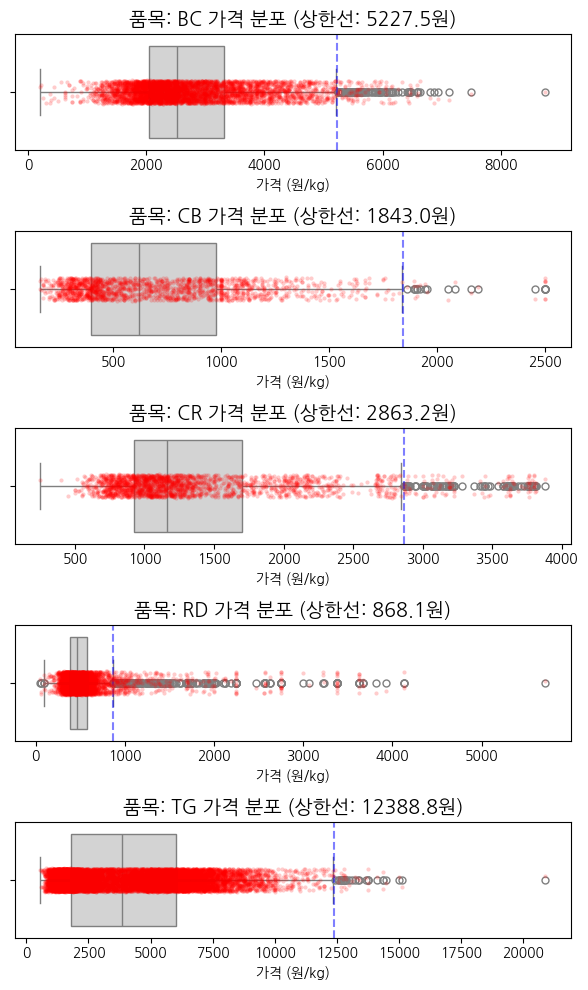

In [13]:
fig, axes = plt.subplots(5, 1, figsize=(6, 10))
for i, item_name in enumerate(items):
    # 0원 제외 데이터
    target_df = train[(train['item'] == item_name) & (train['price(원/kg)'] > 0)]
    
    # IQR 계산
    Q1 = target_df['price(원/kg)'].quantile(0.25)
    Q3 = target_df['price(원/kg)'].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    
    # 시각화
    sns.boxplot(data=target_df, x='price(원/kg)', ax=axes[i], color='lightgray', fliersize=5)
    sns.stripplot(data=target_df, x='price(원/kg)', ax=axes[i], color='red', alpha=0.2, size=3)
    
    axes[i].axvline(upper_bound, color='blue', linestyle='--', alpha=0.5, label='Upper Bound')
    axes[i].set_title(f"품목: {item_name} 가격 분포 (상한선: {upper_bound:.1f}원)", fontsize=14)
    axes[i].set_xlabel("가격 (원/kg)")

plt.tight_layout()
plt.show()

* 유독 심하게 튀는 이상치 위치 확인

### 2.3 요일별/날짜유형별 거래 특이성 (Heatmap)
- 일요일 휴장일 패턴 분석

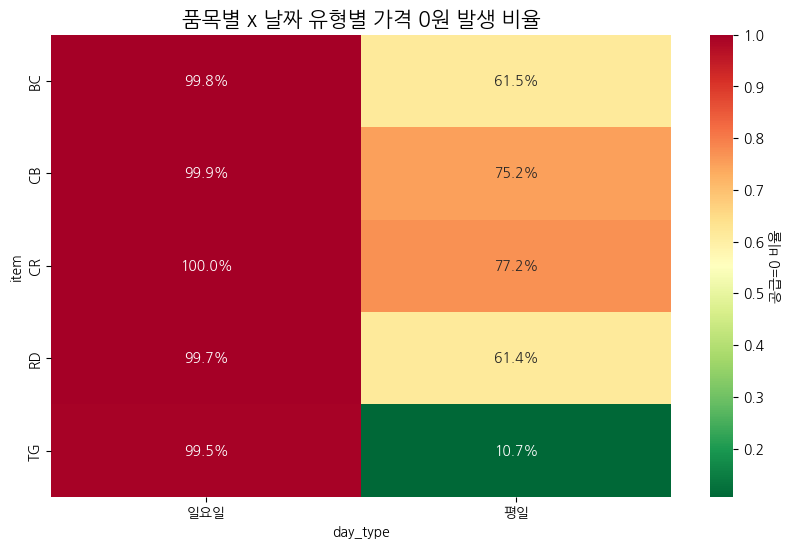

In [14]:
train['dow'] = train['timestamp'].dt.dayofweek
train['is_zero'] = (train['price(원/kg)'] == 0).astype(int)
train['day_type'] = train['dow'].map({0:'평일', 1:'평일', 2:'평일', 3:'평일', 4:'평일', 5:'평일', 6:'일요일'})

pivot = train.groupby(['item', 'day_type'])['is_zero'].mean().unstack()
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.1%', cmap='RdYlGn_r', cbar_kws={'label': '공급=0 비율'})
plt.title('품목별 x 날짜 유형별 가격 0원 발생 비율', fontsize=15)
plt.show()

* 일요일 데이터의 후처리가 필요

### 2.4 명절(설날/추석) 전후 가격 변동 패턴
- 명절 당일 기준 -15일 ~ +5일 추세 분석

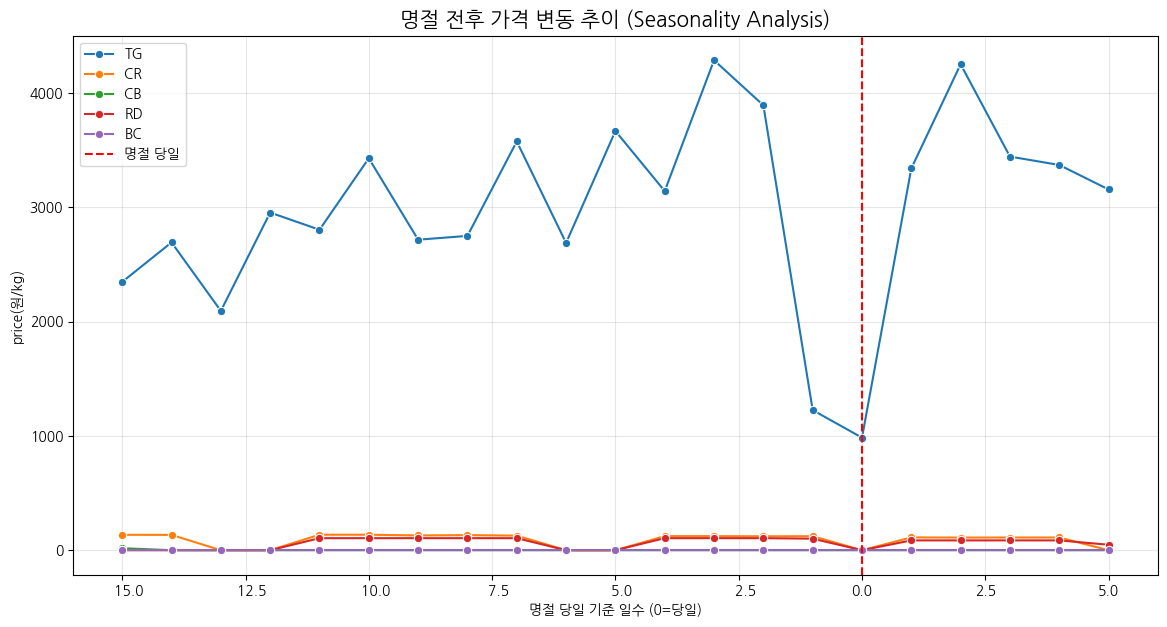

In [15]:
def get_trad_holidays(years):
    kr_h = holidays.KR(years=years)
    return sorted([date for date, name in kr_h.items() if any(k in name for k in ['설날', '추석', 'Lunar', 'Chuseok'])])

holiday_dates = get_trad_holidays(range(2019, 2024))

def calc_dist(date):
    diffs = [(pd.Timestamp(h).date() - date.date()).days for h in holiday_dates]
    return min(diffs, key=abs)

train_h = train.copy()
train_h['dist'] = train_h['timestamp'].apply(calc_dist)

plt.figure(figsize=(14, 7))
mask = (train_h['dist'] >= -15) & (train_h['dist'] <= 5)
sns.lineplot(x='dist', y='price(원/kg)', hue='item', data=train_h[mask], marker='o', errorbar=None)
plt.axvline(0, color='red', linestyle='--', label='명절 당일')
plt.title('명절 전후 가격 변동 추이 (Seasonality Analysis)', fontsize=15)
plt.xlabel('명절 당일 기준 일수 (0=당일)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

* 명절 전후로 가격이 떨어지는 경향이 있음.
* 설날, 추석은 음력으로 정해지기 때문에 파생변수 생성 시 신경 써야함

--- 
## 3. 특성 공학 (Feature Engineering)

### 3.1 이상치 보정 및 파생 변수 생성

In [17]:
# 1. 이상치 보정 (1등 전략)
outlier_thresholds = {'TG': 20000, 'RD': 5000, 'BC': 8000, 'CB': 2300}
for item, thr in outlier_thresholds.items():
    mask = (train['item'] == item) & (train['price(원/kg)'] > thr)
    if mask.any():
        mean_val = train[(train['item'] == item) & (train['price(원/kg)'] > 0)]['price(원/kg)'].mean()
        train.loc[mask, 'price(원/kg)'] = mean_val

# 2. 명절 상수 날짜
SEOLLAL = [pd.Timestamp(d) for d in ['2019-02-05', '2020-01-25', '2021-02-12', '2022-02-01', '2023-01-22']]
CHUSEOK = [pd.Timestamp(d) for d in ['2019-09-13', '2020-10-01', '2021-09-21', '2022-09-10', '2023-09-29']]

def final_preprocess(df):
    df['year'] = df['timestamp'].dt.year
    df['month'] = df['timestamp'].dt.month
    df['day'] = df['timestamp'].dt.day
    df['dow'] = df['timestamp'].dt.dayofweek
    df['week_num'] = (df['timestamp'] - pd.to_datetime('2019-01-01')).dt.days // 7
    df['dist_seollal'] = df['timestamp'].map(lambda d: min(min(abs((d - h).days) for h in SEOLLAL), 30))
    df['dist_chuseok'] = df['timestamp'].map(lambda d: min(min(abs((d - h).days) for h in CHUSEOK), 30))
    kr_h = holidays.KR()
    df['holiday'] = df['timestamp'].apply(lambda x: 1 if x in kr_h else 0)
    return df

train_processed = final_preprocess(train.copy())
test_processed = final_preprocess(test.copy())

# 3. 휴일 보정
no_holiday = train_processed[(train_processed['holiday']==1) & (train_processed['price(원/kg)']>0)]['timestamp'].unique()
train_processed.loc[train_processed['timestamp'].isin(no_holiday), 'holiday'] = 0
test_processed.loc[test_processed['timestamp'].isin(no_holiday), 'holiday'] = 0

# 4. EMA 생성 (0원 제외)
def calc_ema(series, window):
    s = series.replace(0, np.nan)
    ema = s.shift(1).ewm(span=window, min_periods=1).mean()
    return ema.ffill().fillna(0)

for w in [7, 30]:
    train_processed[f'ema_{w}'] = train_processed.groupby(['item', 'corporation', 'location'])['price(원/kg)'].transform(lambda x: calc_ema(x, w))

last_ema = train_processed.groupby(['item', 'corporation', 'location'])[[f'ema_{7}', f'ema_{30}']].last().reset_index()
test_processed = pd.merge(test_processed, last_ema, on=['item', 'corporation', 'location'], how='left').fillna(0)
print("전처리 완료")

전처리 완료


## 4. 하이브리드 모델링 (3-Group Ensemble)

### 4.1 타겟 변환 및 데이터 준비

In [18]:
le_cols = ['item', 'corporation', 'location']
le_dict = {col: LabelEncoder().fit(train_processed[col]) for col in le_cols}
for col in le_cols:
    train_processed[col] = le_dict[col].transform(train_processed[col])
    test_processed[col] = le_dict[col].transform(test_processed[col])

item_codes = {name: le_dict['item'].transform([name])[0] for name in le_dict['item'].classes_}
train_processed['target'] = np.where(train_processed['item'] == item_codes['TG'], np.sqrt(train_processed['price(원/kg)']), np.log1p(train_processed['price(원/kg)']))

feats = ['item', 'corporation', 'location', 'year', 'month', 'day', 'dow', 'week_num', 'holiday', 'dist_seollal', 'dist_chuseok', 'ema_7', 'ema_30']
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(train_processed[feats]), columns=feats)
X_test_scaled = pd.DataFrame(scaler.transform(test_processed[feats]), columns=feats)

### 4.2 모델 학습

In [19]:
def build_dnn(input_shape):
    model = keras.Sequential([
        layers.Dense(256, activation='relu', input_shape=(input_shape,)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mae')
    return model

def train_hybrid(train_df, scaled_df, target_col, test_scaled_df, name=""):
    kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
    preds = []
    for fold, (tr_idx, val_idx) in enumerate(kf.split(train_df)):
        X_tr, y_tr = scaled_df.iloc[tr_idx], train_df[target_col].iloc[tr_idx]
        X_va, y_va = scaled_df.iloc[val_idx], train_df[target_col].iloc[val_idx]
        
        tree = VotingRegressor([
            ('lgbm', LGBMRegressor(n_estimators=1000, learning_rate=0.01, random_state=SEED, verbose=-1)),
            ('xgb', XGBRegressor(n_estimators=1000, learning_rate=0.01, random_state=SEED)),
            ('cat', CatBoostRegressor(iterations=1000, learning_rate=0.01, random_state=SEED, verbose=0))
        ])
        tree.fit(X_tr, y_tr)
        tree_pred = tree.predict(test_scaled_df)
        
        dnn = build_dnn(X_tr.shape[1])
        es = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
        dnn.fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=150, batch_size=128, callbacks=[es], verbose=0)
        dnn_pred = dnn.predict(test_scaled_df).flatten()
        
        preds.append((tree_pred * 0.6) + (dnn_pred * 0.4))
        print(f"{name} Fold {fold+1} 완료")
    return np.mean(preds, axis=0)

m1 = train_processed['item'] == item_codes['TG']
m2 = train_processed['item'].isin([item_codes['RD'], item_codes['CR']])
m3 = train_processed['item'].isin([item_codes['BC'], item_codes['CB']])

print("Group 1 학습...")
p1 = train_hybrid(train_processed[m1], X_train_scaled[m1], 'target', X_test_scaled[test_processed['item']==item_codes['TG']], "TG")
print("Group 2 학습...")
p2 = train_hybrid(train_processed[m2], X_train_scaled[m2], 'target', X_test_scaled[test_processed['item'].isin([item_codes['RD'], item_codes['CR']])], "RD_CR")
print("Group 3 학습...")
p3 = train_hybrid(train_processed[m3], X_train_scaled[m3], 'target', X_test_scaled[test_processed['item'].isin([item_codes['BC'], item_codes['CB']])], "BC_CB")

Group 1 학습...


I0000 00:00:1773716667.596626  144867 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4441 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:01:00.0, compute capability: 8.6
2026-03-17 12:04:31.397490: I external/local_xla/xla/service/service.cc:163] XLA service 0x7b7560003f90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-17 12:04:31.397546: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3070, Compute Capability 8.6
2026-03-17 12:04:31.439460: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-17 12:04:31.714024: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-03-17 12:04:31.881697: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs wer

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step
TG Fold 1 완료
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step
TG Fold 2 완료
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step
TG Fold 3 완료
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step
TG Fold 4 완료
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step
TG Fold 5 완료
Group 2 학습...


2026-03-17 12:08:24.105145: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 12:08:24.105202: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 12:08:24.105224: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 12:08:24.105262: I external/l

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step
RD_CR Fold 1 완료
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
RD_CR Fold 2 완료
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
RD_CR Fold 3 완료
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
RD_CR Fold 4 완료
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
RD_CR Fold 5 완료
Group 3 학습...


2026-03-17 12:15:25.242814: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 12:15:25.242874: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 12:15:25.242887: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 12:15:25.242901: I external/l

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step
BC_CB Fold 1 완료
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 330ms/step
BC_CB Fold 2 완료


2026-03-17 12:17:59.083704: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 12:17:59.083770: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 12:17:59.083785: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 12:17:59.083799: I external/l

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
BC_CB Fold 3 완료
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
BC_CB Fold 4 완료
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
BC_CB Fold 5 완료


## 5. 결과 통합 및 강력한 후처리

In [20]:
test_tg = test_processed[test_processed['item'] == item_codes['TG']].copy()
test_rd_cr = test_processed[test_processed['item'].isin([item_codes['RD'], item_codes['CR']])].copy()
test_bc_cb = test_processed[test_processed['item'].isin([item_codes['BC'], item_codes['CB']])].copy()

test_tg['answer'] = np.power(np.maximum(0, p1), 2)
test_rd_cr['answer'] = np.expm1(p2)
test_bc_cb['answer'] = np.expm1(p3)

final_df = pd.concat([test_tg, test_rd_cr, test_bc_cb])
inv_map = {v: k for k, v in item_codes.items()}
final_df['item_name'] = final_df['item'].map(inv_map)

th = {'TG': 400, 'CB': 50, 'RD': 10, 'CR': 150, 'BC': 100}
for it, val in th.items():
    final_df.loc[(final_df['item_name'] == it) & (final_df['answer'] < val), 'answer'] = 0
final_df.loc[final_df['dow'] == 6, 'answer'] = 0

sub = pd.read_csv('./data/sample_submission.csv')
sub = pd.merge(sub[['ID']], final_df[['ID', 'answer']], on='ID', how='left')
sub.to_csv('submission42.csv', index=False)
print("최종 결과 저장 완료 (submission42.csv)")

최종 결과 저장 완료 (submission42.csv)
